# 1)-3) Выбор набора данных и предварительная обработка.

Для второй части лабораторной работы, посвященной изучению стекинга, многослойного персептрона и методов группового учета аргументов (МГУА), был выбран датасет California Housing Dataset. Выбор обусловлен тем, что библиотека gmdh в настоящее время поддерживает только задачи регрессии, а данный набор является стандартным для регрессионных моделей.

Датасет содержит 20640 объектов и 8 признаков, описывающих различные характеристики жилья в Калифорнии (медианный доход, возраст дома, среднее количество комнат и спален, население, географические координаты и др.). Целевая переменная—median_house_value (медианная стоимость дома в сотнях тысяч долларов). Пропуски в данных отсутствуют.
На этапе предобработки выполнено масштабирование всех признаков с помощью StandardScaler, что необходимо для корректной работы нейронной сети и методов МГУА. Данные разделены на обучающую (80%, 16512 объектов) и тестовую (20%, 4128 объектов) выборки.

Загрузка данных:
Размер датасета: 20640 объектов, 8 признаков

Признаки: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Целевая переменная: median_house_value (средняя стоимость дома)
Диапазон цен: от 0.15 до 5.00 (в сотнях тысяч долларов)

Первые 5 строк:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Статистика признаков:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.

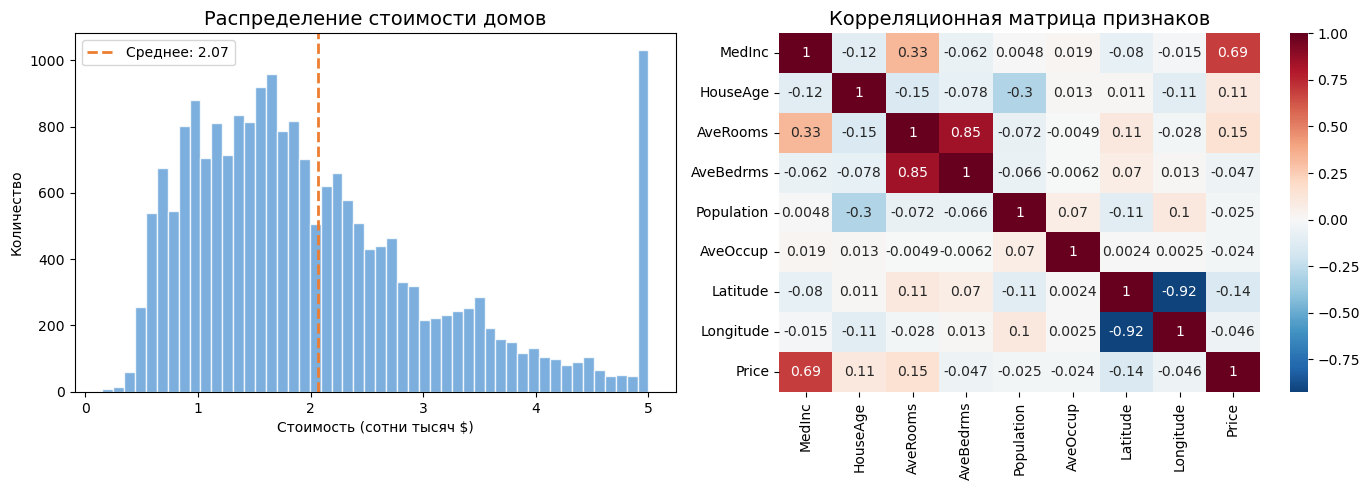

Предобработка данных:
Признаки масштабированы с помощью StandardScaler
Разделение на обучающую и тестовую выборки:
Обучающая выборка: 16512 объектов
Тестовая выборка: 4128 объектов
Количество признаков: 8


In [11]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor


#загружаем встроенный набор California Housing
print("Загрузка данных:")
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(f"Размер датасета: {X.shape[0]} объектов, {X.shape[1]} признаков")
print(f"\nПризнаки: {list(X.columns)}")
print(f"\nЦелевая переменная: median_house_value (средняя стоимость дома)")
print(f"Диапазон цен: от {y.min():.2f} до {y.max():.2f} (в сотнях тысяч долларов)")

print("\nПервые 5 строк:")
print(X.head())

print("\nСтатистика признаков:")
print(X.describe())

print("\nПроверка на пропуски:")
print(X.isnull().sum().sum(), "пропусков")


#визуализация распределения целевой переменной

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#гистограмма цен
axes[0].hist(y, bins=50, color='#5B9BD5', edgecolor='white', alpha=0.8)
axes[0].set_title('Распределение стоимости домов', fontsize=14)
axes[0].set_xlabel('Стоимость (сотни тысяч $)')
axes[0].set_ylabel('Количество')
axes[0].axvline(y.mean(), color='#ED7D31', linestyle='--', linewidth=2, label=f'Среднее: {y.mean():.2f}')
axes[0].legend()

#корреляционная матрица
corr_matrix = pd.DataFrame(np.column_stack([X, y]), 
                           columns=list(X.columns) + ['Price']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, ax=axes[1],
            xticklabels=True, yticklabels=True)
axes[1].set_title('Корреляционная матрица признаков', fontsize=14)

plt.tight_layout()
plt.show()


print("Предобработка данных:")

#масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Признаки масштабированы с помощью StandardScaler")


#разделение train/test
print("Разделение на обучающую и тестовую выборки:")


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")
print(f"Количество признаков: {X_train.shape[1]}")


# 4) Обучение ансамблевых моделей

0. Базовые модели

Для сравнения были обучены три простые модели: линейная регрессия, решающее дерево и случайный лес из 50 деревьев. Они служат ориентиром для оценки эффективности более сложных ансамблевых методов.

1. Стекинг (Stacking)

Стекин- это метод ансамблевого обучения, в котором прогнозы нескольких разнородных моделей первого уровня объединяются с помощью мета-ученика (модели второго уровня). В отличие от бэггинга и бустинга, стекинг использует разные алгоритмы на первом уровне, что обеспечивает разнообразие прогнозов. В данной работе использован StackingRegressor из библиотеки sklearn. Модели первого уровня: Decision Tree, Random Forest (100 деревьев) и Linear Regression. Мета-ученик: Linear Regression. Кросс-валидация: 5.

2. Многослойный персептрон (MLP)

MLP-это нейронная сеть прямого распространения, состоящая из нескольких слоев нейронов. Каждый нейрон применяет нелинейную функцию активации к взвешенной сумме входов. Обучение происходит методом обратного распространения ошибки. Архитектура сети: три скрытых слоя (100, 50 и 25 нейронов), функция активации ReLU, оптимизатор Adam. Для предотвращения переобучения использовали раннюю остановку (early_stopping=True).

In [13]:

#словарь для хранения результатов
results_mae = {}

#базовые модели для сравнения
print("\nБазовые модели (для сравнения)")

#линейная регрессия
lr = LinearRegression()
lr.fit(X_train, y_train)
mae_lr = mean_absolute_error(y_test, lr.predict(X_test))
results_mae['Linear Regression'] = mae_lr
print(f"Linear Regression - MAE: {mae_lr:.4f}")
print(' ')

#дерево решений
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
mae_dt = mean_absolute_error(y_test, dt.predict(X_test))
results_mae['Decision Tree'] = mae_dt
print(f"Decision Tree - MAE: {mae_dt:.4f}")
print(' ')

#случайный лес
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
mae_rf = mean_absolute_error(y_test, rf.predict(X_test))
results_mae['Random Forest'] = mae_rf
print(f"Random Forest - MAE: {mae_rf:.4f}")
print(' ')


#стекинг (Stacking) через sklearn
print("Модель 1: Стекинг (StackingRegressor)")
print("Модели первого уровня: Decision Tree, Random Forest, Linear Regression.")
print("Мета-ученик (final_estimator): Linear Regression.")

start_time = time.time()

#определяем базовые модели (первого уровня)
base_models = [
    ('dt', DecisionTreeRegressor(random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('lr', LinearRegression())
]

#создаем стекинг-регрессор
stacking_reg = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression(),
    cv=5
)

stacking_reg.fit(X_train, y_train)
train_time_stacking = time.time() - start_time

mae_stacking = mean_absolute_error(y_test, stacking_reg.predict(X_test))
results_mae['Stacking'] = mae_stacking

print(f"Время обучения: {train_time_stacking:.2f} сек")
print(f"MAE: {mae_stacking:.4f}")
print(' ')


#многослойный персептрон (MLP)
print("Модель 2: Многослойный персептрон (MLP)")
print("Нейронная сеть с тремя скрытыми слоями: 100, 50 и 25 нейронов.")
print("Функция активации: ReLU. Оптимизатор: Adam.")

start_time = time.time()

mlp = MLPRegressor(
    hidden_layer_sizes=(100, 50, 25),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

mlp.fit(X_train, y_train)
train_time_mlp = time.time() - start_time

mae_mlp = mean_absolute_error(y_test, mlp.predict(X_test))
results_mae['MLP'] = mae_mlp

print(f"Время обучения: {train_time_mlp:.2f} сек")
print(f"Количество итераций: {mlp.n_iter_}")
print(f"MAE: {mae_mlp:.4f}")




Базовые модели (для сравнения)
Linear Regression - MAE: 0.5332
 
Decision Tree - MAE: 0.4552
 
Random Forest - MAE: 0.3277
 
Модель 1: Стекинг (StackingRegressor)
Модели первого уровня: Decision Tree, Random Forest, Linear Regression.
Мета-ученик (final_estimator): Linear Regression.
Время обучения: 65.05 сек
MAE: 0.3252
 
Модель 2: Многослойный персептрон (MLP)
Нейронная сеть с тремя скрытыми слоями: 100, 50 и 25 нейронов.
Функция активации: ReLU. Оптимизатор: Adam.
Время обучения: 8.94 сек
Количество итераций: 68
MAE: 0.3483


## Модели МГУА


3. COMBI (линейный алгоритм)

COMBI-это линейный алгоритм из семейства методов группового учета аргументов (МГУА). МГУА — это метод, который автоматически строит оптимальную модель путем последовательного усложнения структуры (послойного выращивания нейронов) до тех пор, пока качество модели улучшается. Это позволяет преодолевать проблему переобучения. COMBI использует только линейные опорные функции для построения модели. Обучение происходит с автоматическим определением оптимальной структуры сети. Модель была обучена с параметром ref_functions='linear', задающим использование линейных комбинаций признаков.

4. MIA (нелинейный алгоритм)

MIA (Multilayered Iterative Algorithm)-это нелинейный алгоритм МГУА, который использует более сложные опорные функции: линейные с ковариацией (linear_cov), квадратичные (quadratic) и кубические (cubic). Это позволяет строить более гибкие и точные модели по сравнению с линейным COMBI. В отличие от традиционных нейронных сетей, структура MIA не задается заранее, а выращивается автоматически в процессе обучения, что является отличительной особенностью всех методов МГУА. При обучении модели была использована валидационная выборка (validation_data=(X_test, y_test)) для контроля переобучения в процессе выращивания слоев.

In [7]:
#принудительная установка gmdhpy в окружение
import sys
import subprocess

result = subprocess.run([sys.executable, "-m", "pip", "install", "gmdhpy"], 
                       capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("Ошибка:", result.stderr)
else:
    print("Установка завершена!")


Установка завершена!


In [29]:
from gmdhpy import gmdh

print("Модель 3: МГУА COMBI (линейный)")


start_time = time.time()

combi_model = gmdh.MultilayerGMDH(ref_functions=gmdh.RefFunctionType.rfLinear)
combi_model.fit(X_train, y_train)
train_time_combi = time.time() - start_time

mae_combi = mean_absolute_error(y_test, combi_model.predict(X_test))
results_mae['COMBI (GMDH)'] = mae_combi

#print(combi_model)
print(f"Время обучения: {train_time_combi:.2f} сек")
print(f"MAE: {mae_combi:.4f}")

print("Модель 4: МГУА MIA (нелинейный)")

start_time = time.time()

mia_model = gmdh.MultilayerGMDH(
    ref_functions=(gmdh.RefFunctionType.rfLinearCov, 
                   gmdh.RefFunctionType.rfQuadratic, 
                   gmdh.RefFunctionType.rfCubic)
)
mia_model.fit(X_train, y_train)
train_time_mia = time.time() - start_time

mae_mia = mean_absolute_error(y_test, mia_model.predict(X_test))
results_mae['MIA (GMDH)'] = mae_mia

#print(mia_model)
print(f"Время обучения: {train_time_mia:.2f} сек")
print(f"MAE: {mae_mia:.4f}")




Модель 3: МГУА COMBI (линейный)
train layer0 in 0.58 sec
train layer1 in 2.55 sec
train layer2 in 2.46 sec
train layer3 in 2.44 sec
train layer4 in 2.49 sec
train layer5 in 2.42 sec
train layer6 in 2.66 sec
train layer7 in 2.60 sec
Время обучения: 18.25 сек
MAE: 0.5340
Модель 4: МГУА MIA (нелинейный)
train layer0 in 3.11 sec
train layer1 in 13.53 sec
train layer2 in 13.81 sec
train layer3 in 15.23 sec
train layer4 in 14.38 sec
train layer5 in 14.23 sec
train layer6 in 13.57 sec
train layer7 in 14.13 sec
train layer8 in 14.08 sec
train layer9 in 14.02 sec
train layer10 in 13.73 sec
train layer11 in 14.02 sec
train layer12 in 13.71 sec
train layer13 in 13.57 sec
train layer14 in 13.98 sec
train layer15 in 15.87 sec
train layer16 in 16.36 sec
train layer17 in 14.23 sec
train layer18 in 14.05 sec
train layer19 in 13.84 sec
train layer20 in 14.61 sec
train layer21 in 14.40 sec
Error training model on train data set, layer index 22
Время обучения: 313.04 сек
MAE: 0.5070


In [17]:

import gmdhpy.gmdh as gmdh
print("Доступные атрибуты в gmdhpy.gmdh:")
for attr in dir(gmdh):
    if not attr.startswith('_'):
        print(f"  - {attr}")

Доступные атрибуты в gmdhpy.gmdh:
  - BaseMultilayerGMDH
  - CriterionType
  - DataSetType
  - GMDHCheckError
  - Layer
  - LayerCreationError
  - Manager
  - MultilayerGMDH
  - MultilayerGMDHparam
  - PolynomModel
  - Pool
  - RefFunctionType
  - SequenceTypeSet
  - StandardScaler
  - linear_model
  - mp
  - np
  - plt
  - predict_preprocessing
  - set_matrix_a
  - six
  - sub_calculate_model_weights
  - sub_calculate_model_weights_helper
  - sys
  - time
  - train_model
  - train_preprocessing


In [35]:
#доступные ref_functions
from gmdhpy import gmdh
print("Доступные типы:")
for attr in dir(gmdh.RefFunctionType):
    if not attr.startswith('_'):
        print(f"  - {attr}")

Доступные типы:
  - rfCubic
  - rfLinear
  - rfLinearCov
  - rfQuadratic
  - rfUnknown


Алгоритм COMBI построил модель из 8 слоев нейронов за 18.25 секунды, достигнув значения MAE=0.534 на тестовой выборке. Использование только линейных опорных функций ограничило сложность модели, но обеспечило быстрое обучение.

Алгоритм MIA с комбинацией линейных, квадратичных и кубических опорных функций построил значительно более глубокую модель из 21 слоя нейронов за 313 секунд и показал лучший результат MAE=0.507. На 22-м слое алгоритм автоматически прекратил обучение, так как качество модели перестало улучшаться. Это демонстрирует ключевую особенность МГУА-встроенный механизм автоматического определения оптимальной сложности модели, предотвращающий переобучение без необходимости ручного подбора гиперпараметров. Более высокое качество по сравнению с COMBI объясняется использованием нелинейных опорных функций.

# 5) Оценка качества моделей и сравнение

Для итоговой оценки качества всех обученных моделей использовались три метрики: MAE (средняя абсолютная ошибка), RMSE (корень из среднеквадратичной ошибки) и R² (коэффициент детерминации). По всем трем метрикам наилучший результат показала модель Stacking (MAE=0.325, RMSE=0.506, R²=0.805). Стекинг объединил прогнозы трех базовых моделей (Decision Tree, Random Forest и Linear Regression) с помощью мета-ученика (Linear Regression), что позволило получить результат, незначительно превосходящий лучшую базовую модель-Random Forest (R²=0.805). 
Многослойный персептрон (MLP) показал близкий результат (R²=0.794), продемонстрировав способность нейронных сетей успешно решать задачи регрессии. Модели МГУА (COMBI и MIA) показали более скромные результаты и их качество оказалось сопоставимо с линейной регрессией и деревом решений соответственно. Это может быть связано с особенностями датасета, где основные зависимости между признаками и целевой переменной достаточно хорошо описываются линейными и древовидными моделями, а автоматически выращенная структура МГУА не смогла найти более эффективного представления. Тот факт, что нелинейный MIA (R²=0.608) превзошел линейный COMBI (R²=0.578), подтверждает преимущество использования более сложных опорных функций при наличии нелинейных закономерностей в данных.


Результаты оценки качества на тестовой выборке:
Модель                   MAE         RMSE        R²          
Linear Regression        0.5332      0.7456      0.5758      
Decision Tree            0.4552      0.7060      0.6197      
Random Forest            0.3277      0.5058      0.8047      
Stacking                 0.3252      0.5058      0.8048      
MLP                      0.3483      0.5192      0.7943      
COMBI (GMDH)             0.5340      0.7434      0.5782      
MIA (GMDH)               0.5070      0.7163      0.6084      

Лучшая модель по MAE:  Stacking (0.3252)
Лучшая модель по RMSE: Stacking (0.5058)
Лучшая модель по R²:   Stacking (0.8048)


/var/folders/9x/jfwvlbln56qbxr_2zb3s_rc00000gn/T/ipykernel_14403/3734052964.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(model_names, rotation=45, ha='right')


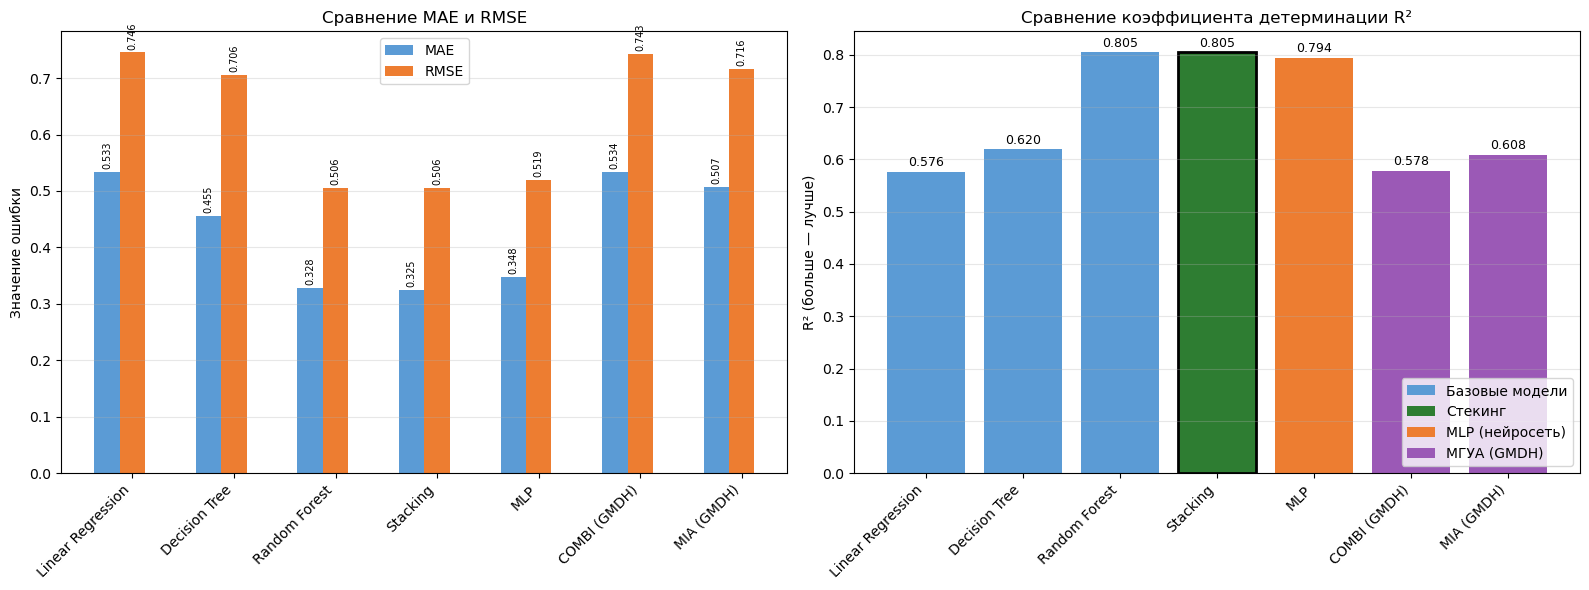

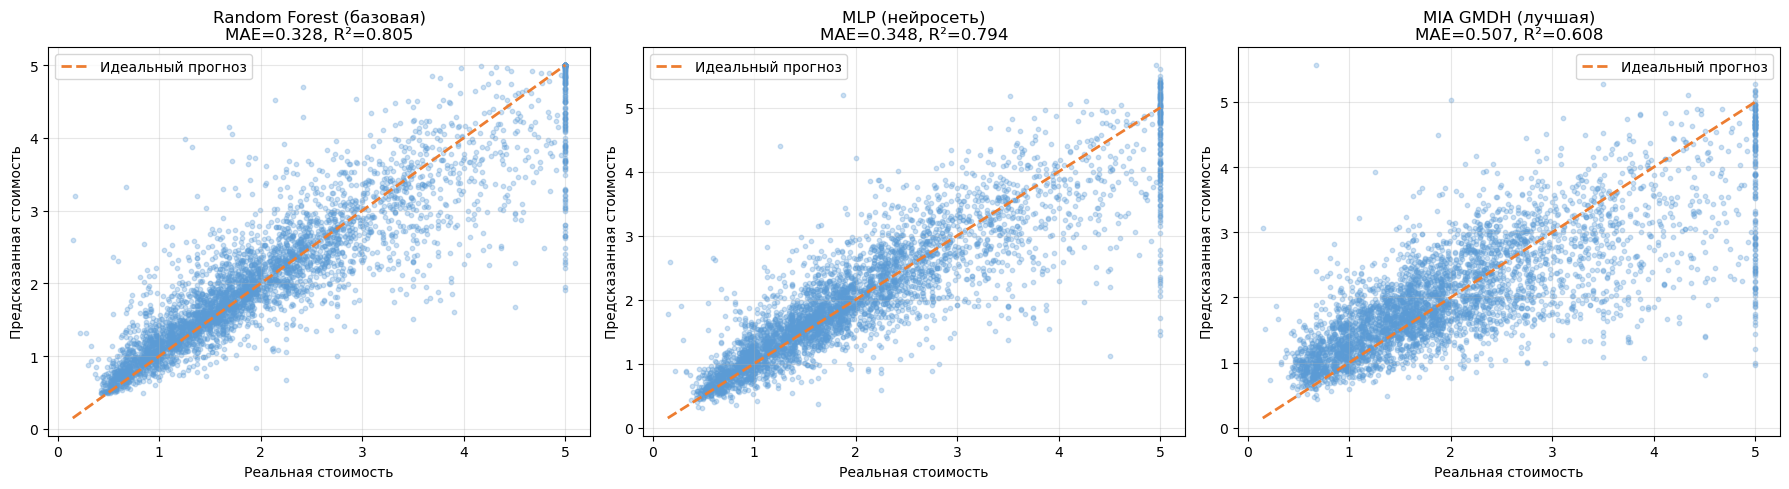

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from matplotlib.patches import Patch


#расчет метрик для всех моделей

results_full = {}

models_dict = {
    'Linear Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'Stacking': stacking_reg,
    'MLP': mlp,
    'COMBI (GMDH)': combi_model,
    'MIA (GMDH)': mia_model
}

for name, model in models_dict.items():
    y_pred = model.predict(X_test)
    results_full[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R²': r2_score(y_test, y_pred)
    }

print("\nРезультаты оценки качества на тестовой выборке:")

print(f"{'Модель':<25}{'MAE':<12}{'RMSE':<12}{'R²':<12}")


for name in models_dict.keys():
    m = results_full[name]
    print(f"{name:<25}{m['MAE']:<12.4f}{m['RMSE']:<12.4f}{m['R²']:<12.4f}")

#находим лучшие модели по каждой метрике
best_mae = min(results_full, key=lambda x: results_full[x]['MAE'])
best_rmse = min(results_full, key=lambda x: results_full[x]['RMSE'])
best_r2 = max(results_full, key=lambda x: results_full[x]['R²'])

print(f"\nЛучшая модель по MAE:  {best_mae} ({results_full[best_mae]['MAE']:.4f})")
print(f"Лучшая модель по RMSE: {best_rmse} ({results_full[best_rmse]['RMSE']:.4f})")
print(f"Лучшая модель по R²:   {best_r2} ({results_full[best_r2]['R²']:.4f})")


#график 1: сравнение всех метрик (группировка по моделям)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


model_names = list(models_dict.keys())
mae_vals = [results_full[m]['MAE'] for m in model_names]
rmse_vals = [results_full[m]['RMSE'] for m in model_names]
r2_vals = [results_full[m]['R²'] for m in model_names]

x = np.arange(len(model_names))
width = 0.25

#mae и rmse (меньше=лучше)
bars1 = axes[0].bar(x - width, mae_vals, width, label='MAE', color='#5B9BD5')
bars2 = axes[0].bar(x, rmse_vals, width, label='RMSE', color='#ED7D31')

axes[0].set_ylabel('Значение ошибки')
axes[0].set_title('Сравнение MAE и RMSE')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

#gодписи значений
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7, rotation=90)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7, rotation=90)

#график 2: r2 (больше=лучше)
bar_colors = []
for name in model_names:
    if name in ['Linear Regression', 'Decision Tree', 'Random Forest']:
        bar_colors.append('#5B9BD5')
    elif name == 'Stacking':
        bar_colors.append('#2E7D32')
    elif name == 'MLP':
        bar_colors.append('#ED7D31')
    else:
        bar_colors.append('#9B59B6')

bars3 = axes[1].bar(model_names, r2_vals, color=bar_colors)
axes[1].set_ylabel('R² (больше — лучше)')
axes[1].set_title('Сравнение коэффициента детерминации R²')
axes[1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

#выделяем лучшую модель по r2
best_r2_idx = model_names.index(best_r2)
bars3[best_r2_idx].set_edgecolor('black')
bars3[best_r2_idx].set_linewidth(2)

#подписи значений
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

legend_elements = [
    Patch(facecolor='#5B9BD5', label='Базовые модели'),
    Patch(facecolor='#2E7D32', label='Стекинг'),
    Patch(facecolor='#ED7D31', label='MLP (нейросеть)'),
    Patch(facecolor='#9B59B6', label='МГУА (GMDH)')
]
axes[1].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()


#график 2: диагр рассеяния для лучшей модели
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#выбираем три модели для сравнения: лучшая базовая, mlp и лучшая gmdh
models_to_plot = {
    'Random Forest (базовая)': rf,
    'MLP (нейросеть)': mlp,
    'MIA GMDH (лучшая)': mia_model
}

for ax, (name, model) in zip(axes, models_to_plot.items()):
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.3, s=10, c='#5B9BD5')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
            '--', color='#ED7D31', linewidth=2, label='Идеальный прогноз')
    
    mae_val = mean_absolute_error(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)
    
    ax.set_xlabel('Реальная стоимость')
    ax.set_ylabel('Предсказанная стоимость')
    ax.set_title(f'{name}\nMAE={mae_val:.3f}, R²={r2_val:.3f}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Вывод

В ходе выполнения второй части лабораторной работы были изучены и применены на практике методы стекинга, многослойного персептрона и группового учета аргументов (МГУА) для решения задачи регрессии на датасете California Housing. Стекинг, объединивший прогнозы трех базовых моделей (Decision Tree, Random Forest и Linear Regression) с помощью мета-ученика, показал наилучший результат по всем метрикам (MAE=0.325, R²=0.805), подтвердив свою эффективность как метода «последней мили» для повышения точности предсказаний. Многослойный персептрон с тремя скрытыми слоями продемонстрировал близкий результат (R²=0.794), что подтверждает способность нейронных сетей успешно моделировать сложные зависимости в данных. Методы МГУА (COMBI и MIA) показали более скромные результаты, уступив как стекингу, так и случайному лесу, однако нелинейный алгоритм MIA ожидаемо превзошел линейный COMBI за счет использования более сложных опорных функций. Важным преимуществом МГУА является встроенный механизм автоматического определения оптимальной структуры модели, что было наглядно продемонстрировано при обучении MIA: алгоритм самостоятельно остановил рост сети на 22-м слое, предотвратив переобучение. Практическое применение изученных методов позволяет для конкретной задачи подобрать оптимальный баланс между точностью модели, временем обучения и интерпретируемостью результатов.